In [3]:
import pandas as pd
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
alpha = 0.05

bids_folder = '/Users/mrenke/data/ds-dnumrisk'
phenotype_folder = '/Users/mrenke/data/ds-dnumrisk/derivatives/phenotype'

groupList =  pd.read_csv(op.join(bids_folder, 'group_mapping.csv'), header=0, index_col=0)
groupList['group'] = np.where(groupList['group'] == 0, 'Control', 'Dyscalculic')

plot_folder = op.join(bids_folder, 'plots_and_ims', 'paper_dnumrisk_01')
os.makedirs(plot_folder, exist_ok=True)
sns.set_context('talk')


In [4]:
from numrisk.behavior_magjudge.utils import get_data

df= get_data(bids_folder,  include_var=['group'])
df = df.sort_index() # so first sub is Control, Control will be plotted first;) 

df['group'] = np.where(df['group'] == 0, 'Control', 'Dyscalculic')
df['n1'] = df['n1'].astype(int)
#df.rename(columns={'n1':'Number range'}, inplace=True)


number of subjects found: 66
number of subjects in dataframe: 66
Int64Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
            18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
            35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
            52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
           dtype='int64', name='subject')


### Raw behavior

In [12]:
# report accuracy and RT in text
import pingouin as pg
df['correct_answer_n2'] = np.where((df['n2'] > df['n1']), True, False)
df['correct'] = np.where((df['correct_answer_n2'] == df['chose_n2']), True, False)

tmp = df.set_index('group', append=True)
tmp = tmp.groupby(['subject','group']).mean().reset_index()

from scipy.stats import ttest_ind, mannwhitneyu, normaltest

for y_var in ['correct', 'rt']:
    ctrl = tmp.loc[tmp['group']=='Control', y_var]
    dys  = tmp.loc[tmp['group']=='Dyscalculic', y_var]

    ctrl_mean, ctrl_sd = ctrl.mean(), ctrl.std()
    dys_mean, dys_sd   = dys.mean(), dys.std()

    pooled = tmp[y_var].dropna()
    _, p_normal = normaltest(pooled)

    if p_normal > alpha:
        stat, pval = ttest_ind(ctrl, dys)
        test = "t"
        stat_label = f"t = {stat:.2f}"
    else:
        stat, pval = mannwhitneyu(ctrl, dys, alternative="two-sided")
        test = "MWU"
        stat_label = f"U = {stat:.0f}"
    #print(stats)
    print(f"{y_var}: Control {tmp.loc[tmp['group']=='Control', y_var].mean():.2f} +- {tmp.loc[tmp['group']=='Control', y_var].std():.2f}, Dyscalculic {tmp.loc[tmp['group']=='Dyscalculic', y_var].mean():.2f} +- {tmp.loc[tmp['group']=='Dyscalculic', y_var].std():.2f})")
    print(f"{stat_label}, p={pval:.3f}")



correct: Control 0.87 +- 0.05, Dyscalculic 0.85 +- 0.07)
U = 654, p=0.164
rt: Control 1.26 +- 0.30, Dyscalculic 1.44 +- 0.42)
U = 392, p=0.051


### Psychometric model

In [5]:
# psychometric

import bambi # behav_fit2_copy
import arviz as az

model_label = 2
target_folder = op.join(bids_folder, f'derivatives/cogmodels_magjudge')
df['x'] = df['log(n2/n1)'] 

#model = bambi.Model('chose_n2 ~ x + x*n1*group + (x*n1|subject)', link='probit', family='bernoulli', data=df.reset_index())
traces = az.from_netcdf( op.join(target_folder, f'probit_model-{model_label}_trace.netcdf'))

Number range: p=0.96375, mean=0.013102677868606508, 95%CI=[-0.00106698  0.02753195]
Slope: p=0.063, mean=-0.5751384399598628, 95%CI=[-1.30818567  0.16105182]


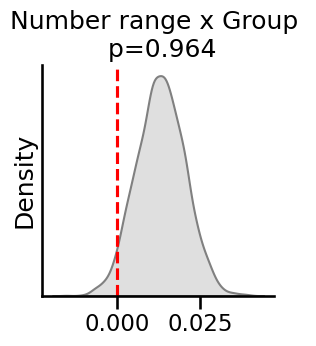

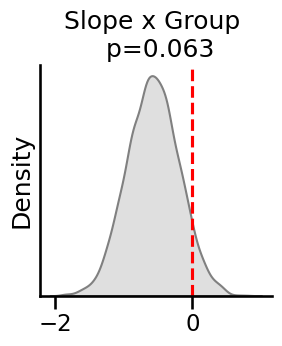

In [7]:
for regressor, name in zip(['n1:group', 'x:group'], ['Number range', 'Slope']):
    temp = traces.posterior[regressor].to_dataframe()
    print(f'{name}: p={np.mean(temp[regressor] > 0)}, mean={np.mean(temp[regressor])}, 95%CI={np.percentile(temp[regressor], [2.5, 97.5])}')

    count_greater_zero = np.round(np.mean(temp[regressor] > 0),3)

    fig, axs = plt.subplots(1,1, figsize=(3,3), sharex=False)
    sns.kdeplot(temp[regressor], ax=axs,legend=False, fill=True, color='grey')
    axs.set(yticks=[],ylabel='Density',xlabel='')
    axs.axvline(x=0, color='r', linestyle='--')
    axs.set_title(f'{name} x Group \n p={count_greater_zero}')
    sns.despine()
    plt.savefig(op.join(plot_folder, f'mag_psychometric_{regressor}.pdf'), bbox_inches='tight')

In [6]:
traces = az.from_netcdf( op.join(target_folder, f'probit_model-{model_label}_trace.netcdf'))
for regressor, name in zip(['n1', 'x'], ['Number range', 'Slope']):
    temp = traces.posterior[regressor].to_dataframe()
    print(f'{name}: p={np.mean(temp[regressor] > 0)}, mean={np.mean(temp[regressor])}, 95%CI={np.percentile(temp[regressor], [2.5, 97.5])}')


Number range: p=1.0, mean=0.03426855188141974, 95%CI=[0.02425891 0.04460338]
Slope: p=1.0, mean=5.328738339794891, 95%CI=[4.78816969 5.8702809 ]


## Cognitive model

In [8]:
# bauer model 
import arviz as az
from bauer.utils.bayes import softplus

target_folder = op.join(bids_folder, f'derivatives/cogmodels_magjudge')
traces =  az.from_netcdf(op.join(target_folder, f'model-3_trace.netcdf'))

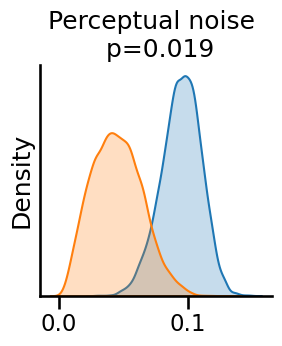

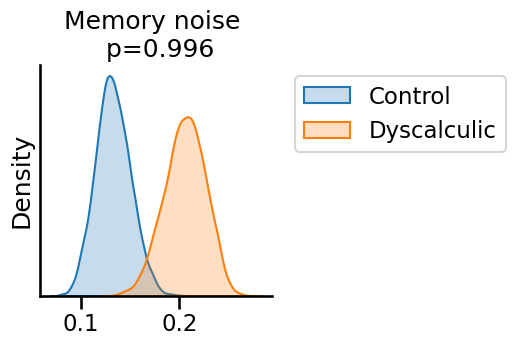

In [4]:
from bauer.utils.bayes import softplus

for noise in ['perceptual', 'memory']:
    tmp = traces.posterior[f'{noise}_noise_sd_mu'].to_dataframe()

    tmp = tmp.unstack(f'{noise}_noise_sd_regressors')
    control = tmp.xs('Intercept', 1, level=1)
    control = control.rename(columns={f'{noise}_noise_sd_mu':'Control'})
    control = softplus(control)
    dys = tmp.xs('Intercept', 1, level=1) + tmp.xs('group', 1, level=1)
    dys = dys.rename(columns={f'{noise}_noise_sd_mu':'Dyscalculic'})
    dys = softplus(dys)
    comb = pd.concat([control, dys], axis=1)
    comb['dif'] = comb['Dyscalculic'] - comb['Control']
    count_greater_zero = np.round(np.mean(comb['dif'] > 0),3)

    plt.figure(figsize=(3,3))
    sns.kdeplot(control, color='blue', fill=True, label='Control',legend=False)
    sns.kdeplot(dys['Dyscalculic'],  color=sns.color_palette()[1], fill=True, label='Dyscalculic')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') if noise== 'memory' else None
    plt.xlabel('')
    plt.yticks([])
    plt.title(f'{noise.capitalize()} noise \n p={count_greater_zero}')
    sns.despine()
    plt.savefig(op.join(plot_folder, f'mag_bauer-3_{noise}_control-dys.pdf'), bbox_inches='tight')

In [ ]:
# Statistics 
from bauer.utils.bayes import softplus

for noise in ['perceptual', 'memory']:
    tmp = traces.posterior[f'{noise}_noise_sd_mu'].to_dataframe()

    tmp = tmp.unstack(f'{noise}_noise_sd_regressors')
    control = tmp.xs('Intercept', 1, level=1)
    control = control.rename(columns={f'{noise}_noise_sd_mu':'Control'})
    control = softplus(control)
    dys = tmp.xs('Intercept', 1, level=1) + tmp.xs('group', 1, level=1)
    dys = dys.rename(columns={f'{noise}_noise_sd_mu':'Dyscalculic'})
    dys = softplus(dys)
    comb = pd.concat([control, dys], axis=1)
    comb['dif'] = comb['Dyscalculic'] - comb['Control']

    print(f'{noise} noise difference: p={np.mean(comb["dif"] > 0)}, mean dif={np.mean(comb["dif"])}, 95%CI={np.percentile(comb["dif"], [2.5, 97.5])}')
    for group in ['Control', 'Dyscalculic']:
        print(f'{group} mean {noise} noise: {np.mean(comb[group])}, 95%CI={np.percentile(comb[group], [2.5, 97.5])}')   

perceptual noise difference: p=0.019166666666666665, mean dif=-0.04952328163016748, 95%CI=[-0.09411248 -0.00231815]
Control mean perceptual noise: 0.09461605588780102, 95%CI=[0.06204503 0.12247037]
Dyscalculic mean perceptual noise: 0.045092774257633535, 95%CI=[0.01146922 0.08530761]
memory noise difference: p=0.9959166666666667, mean dif=0.07275181718781693, 95%CI=[0.02003671 0.12370688]
Control mean memory noise: 0.13264491545610885, 95%CI=[0.0996695 0.1691601]
Dyscalculic mean memory noise: 0.20539673264392577, 95%CI=[0.16258226 0.24300133]


## Neural statistics


In [8]:
df_decode = pd.read_csv(op.join(phenotype_folder, 'decoding_r.csv')).set_index('subject').join(groupList)


In [12]:
df_decode

,r,group
subject,,
1,-0.058083,Control
2,0.206071,Dyscalculic
4,-0.089840,Dyscalculic
5,-0.023735,Control
6,0.062036,Dyscalculic
...,...,...
62,0.305624,Control
63,0.165065,Control
64,0.274937,Control


r - normal distribution (fail to reject H0)
TtestResult(statistic=-0.15137739830488958, pvalue=0.8801617118515485, df=63.0)


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


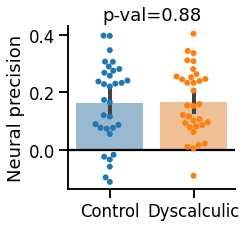

In [21]:
y_var = 'r'

tmp = df_decode.set_index('group', append=True)


figure, axes = plt.subplots(1, 1,figsize = (3,3))
sns.barplot(data=tmp.reset_index(), x ='group',y=y_var, alpha=0.5) # hue='group' ,legend=False
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])

if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)
axes.set(title=f'p-val={stats.pvalue:.2f}',
    ylabel='Neural precision', xlabel=None)#,ylim=[0,15])
axes.axhline(0, color='black')#, linestyle='--')
sns.despine()
print(stats)